# Forward Modelling Magnetics

In this notebook the user can:

1. Import a pre-made plutonic model as a pkl file (Section 3).
2. Define a regular measurement grid (Section 4).
3. Create an array of susceptibility values for the plutonite and the basement (Section 5).
4. Varify if the susceptibility values allign with geology (Section 7).
5. Perform magnetic forward modelling on a regular grid (Section 8).
    
    Warning: the user must specify the external magnetic field strength and inclination and declination depending on the location of the survey.
6. Confirm the forward modelling is working correctly by working with a simple burried dipole and varying the depth and inclincation and declination of the external field (Section 10).

# Loose Ends

- Assigning a susceptibility array and the magnetic engine from NumpyMagneticsForwardModeling should be restructured in the same way as is done for the gravity engine. This will be a more Object Orientated Programming rather than Scientific Programming which I have mostly done.
- The boudary effects should be investigated and resolved. When calculating the forward magnetic results, only the voxels within a certain range of the 'sensor' are taken account of. This is possibly creating the boundary effects as no voxels are present outside of the boundary.
- The burried dipole serves as an example and playground for the forward magnetic operator. Somebody should verify if the results make physical sense for external magnetic fields at e.g., the north pole or the equator. I checked it and it looks alright, but it should be double checked.


# 1. Packages

In [27]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd

from mpl_toolkits.mplot3d import Axes3D

import gempy as gp
import gempy_viewer as gpv
import gempy_engine

from gempy_engine.core.data.stack_relation_type import StackRelationType

import threading
import pickle
import os

from forward_modelling_magnetics_python import NumpyMagneticsForwardModeling
import magnetic_dipole_example as examples
from forward_modelling_magnetics_python import visualize_magnetic_results
import misfit

BASE_DIR = os.getcwd()
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')
geomodel_dir = os.path.abspath(os.path.join(BASE_DIR, '..', '..', 'Data', 'Geological_Models'))
geophysical_dir = os.path.abspath(os.path.join(BASE_DIR, '..', '..', 'Data', 'Input_Data', 'Geophysical_Cleaned_Data'))

trigger_create_cross_section = True

# 2. Model Parameters

In [3]:
# Model Extent
min_x = -707522
max_x = -677518
min_y =  4528453
max_y =  4549947
max_z =  505
model_depth = -500

# Set the extent of the model
extent=[min_x, max_x, max_y, min_y, model_depth, max_z]

# Set model resolution
nx = ny = nz = 64  # Define grid resolution
resolution = [nx, ny, nz]

# Topography
path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced_sf0.1.tif')

# Plutonite dip angle
plutonite_dip_angle = 70 # 70

# 3. Importing Plutonic Model

In [4]:
# --- Load full model ---
with open(os.path.join(geomodel_dir, 'Plutonite-Basement_Models', 'plutonite_geo_model.pkl'), "rb") as f:
    plutonite_geo_model = pickle.load(f)

# 4. Defining a Measurement Grid

In [5]:
# Define a measurement resolution
mag_res = 25

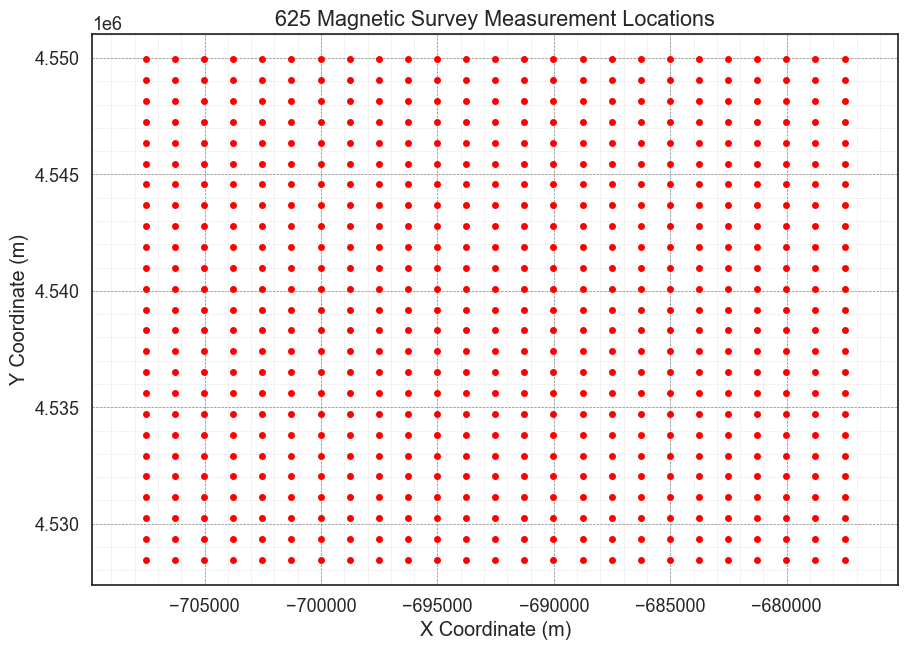

In [6]:
# Creating measurement devices for magnetic survey - using same grid as gravity
X_mag = np.linspace(min_x, max_x, mag_res)
Y_mag = np.linspace(min_y, max_y, mag_res)
Z_mag = max_z
xyz_mag = np.meshgrid(X_mag, Y_mag, Z_mag)
xy_ravel_mag = np.vstack(list(map(np.ravel, xyz_mag))).T

plt.plot(xy_ravel_mag[:,0], xy_ravel_mag[:,1], 'o', color='red', markersize=5)
plt.grid(which='major', color='grey', linestyle='--', linewidth=0.5)
plt.minorticks_on()
plt.grid(which='minor', color='lightgrey', linestyle=':', linewidth=0.5)
plt.xlabel('X Coordinate (m)')
plt.ylabel('Y Coordinate (m)')
plt.title(f'{len(xy_ravel_mag)} Magnetic Survey Measurement Locations')
plt.axis('equal')
plt.show()

# 5. Assigning Susceptibility Values

In [7]:
non_plutonite_susceptibility = 0.01
plutonite_susceptibility     = 0.05

In [8]:

# 1. Get the formation IDs for the model
plutonite_lith_block = plutonite_geo_model.solutions.raw_arrays.lith_block
plutonite_lith_block_reshaped = plutonite_lith_block.reshape(64,64,64)

# 2. Get the coordinates of these voxels
voxel_coords = plutonite_geo_model.grid.regular_grid.values
voxel_coords_reshaped = voxel_coords.reshape(64, 64, 64, 3)

# 3. Flip Y coordinate
y_min, y_max = np.min(voxel_coords[:, 1]), np.max(voxel_coords[:, 1])
voxel_coords_flipped = voxel_coords.copy()
voxel_coords_flipped[:, 1] = y_max - (voxel_coords[:, 1] - y_min)

# 2. Identify the formation ID of the Plutonite
plutonite_id = 1

# 3. Create a boolean mask for plutonite voxels
plutonite_mask = plutonite_lith_block_reshaped == plutonite_id

# 4. Create a susceptibility array
susceptibility_array = np.full(plutonite_lith_block_reshaped.shape, non_plutonite_susceptibility)  # Default susceptibility for non-plutonite voxels
susceptibility_array[plutonite_mask] = plutonite_susceptibility                                    # Higher susceptibility for plutonite voxels
susceptibility_array_flat = susceptibility_array.flatten()

print(f"Susceptibility array shape: {susceptibility_array_flat.shape}")
print(f"Number of plutonite voxels: {np.sum(plutonite_mask)}")
print(f"Susceptibility range: {np.min(susceptibility_array_flat):.3f} to {np.max(susceptibility_array_flat):.3f}")

# Formation ID's
# 1 = Plutonites
# 2 = Basement

Susceptibility array shape: (262144,)
Number of plutonite voxels: 135445
Susceptibility range: 0.010 to 0.050


# 6. Save the Susceptibility Array

In [9]:
np.save("your_susceptibility.npy", susceptibility_array)

# 7. Visualise the Susceptibility Distribution

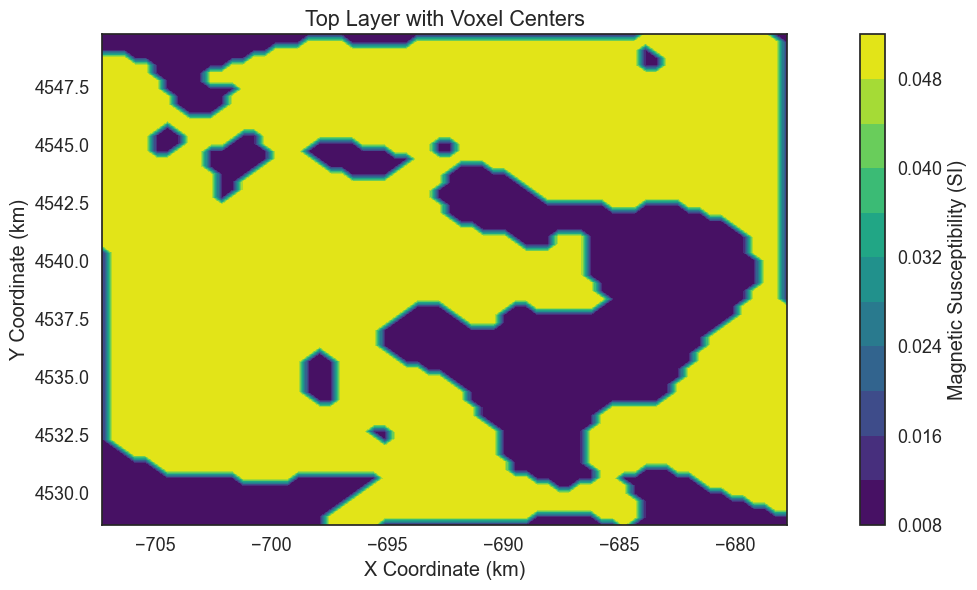

In [11]:
# Extract top layer voxel coordinates and susceptibility values
# Use flipped voxel coordinates for proper orientation
voxel_coords_flipped_reshaped = voxel_coords_flipped.reshape(64, 64, 64, 3)
top_layer_coords = voxel_coords_flipped_reshaped[:, :, -1, :]  # Top layer (highest z)
top_layer_susceptibility = susceptibility_array[:, :, -1]      # Top layer susceptibility

# Extract X and Y coordinates for plotting
x_top = top_layer_coords[:, :, 0]
y_top = top_layer_coords[:, :, 1]

# Create visualization
fig, ax = plt.subplots(figsize=(15, 6))

# Contour plot of susceptibility values
contour = ax.contourf(x_top/1000, y_top/1000, top_layer_susceptibility, levels=10, cmap='viridis')
cbar2 = plt.colorbar(contour, ax=ax)
cbar2.set_label('Magnetic Susceptibility (SI)')
ax.set_xlabel('X Coordinate (km)')
ax.set_ylabel('Y Coordinate (km)')
ax.set_title('Top Layer with Voxel Centers')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# 8. Perform Magnetic Forward Modelling

In [12]:
voxel_centers = voxel_coords_flipped
voxel_sizes = np.array([plutonite_geo_model.grid.regular_grid.dx,
                         plutonite_geo_model.grid.regular_grid.dy,
                         plutonite_geo_model.grid.regular_grid.dz])
measurement_points = xy_ravel_mag

The user is able to define a cutoff distance and local inclination, declination and external field strength depending on the location.

In [12]:

mag_engine = NumpyMagneticsForwardModeling(cutoff_distance=5000.0)
mag_engine.set_magnetic_parameters(B_ext=50e-6, incl=60.0, decl=0.43)

results = mag_engine.load_and_process_model(
    "your_susceptibility.npy", 
    voxel_centers, 
    voxel_sizes, 
    measurement_points
)

Loading susceptibility model from your_susceptibility.npy
Loaded susceptibility model with shape: (64, 64, 64)
Processing 625 measurement points with 262144 voxels
Computing volume integrals for 262144 voxels and 625 measurements...
Using distance cutoff: 5.0 km
Pre-computing active voxels within cutoff distance...
  Measurement point 1: 7905/262144 active voxels (3.0%)
Processing 625 measurement points with 262144 voxels
Computing volume integrals for 262144 voxels and 625 measurements...
Using distance cutoff: 5.0 km
Pre-computing active voxels within cutoff distance...
  Measurement point 1: 7905/262144 active voxels (3.0%)
Total active voxel-measurement pairs: 15870816 (vs 163840000 without cutoff)
Computational reduction: 90.3%
Processing measurements 1 to 625 of 625
Total active voxel-measurement pairs: 15870816 (vs 163840000 without cutoff)
Computational reduction: 90.3%
Processing measurements 1 to 625 of 625
Volume integrals computed in 32.36 seconds
Computing magnetic forward

# 9. Visualise the Results

Because we did not implement a centered grid yet as done with forward modelling for gravity, there are boundary effects we have to manually remove. This ought to be fixed in the next version of NumpyMagneticsForwardModeling. In the results there are also some unexplained outliers that I had to roughly reduce by clipping the values. Best would be to remove the meaurement points or to smooth them using n number of nearest neighbours.

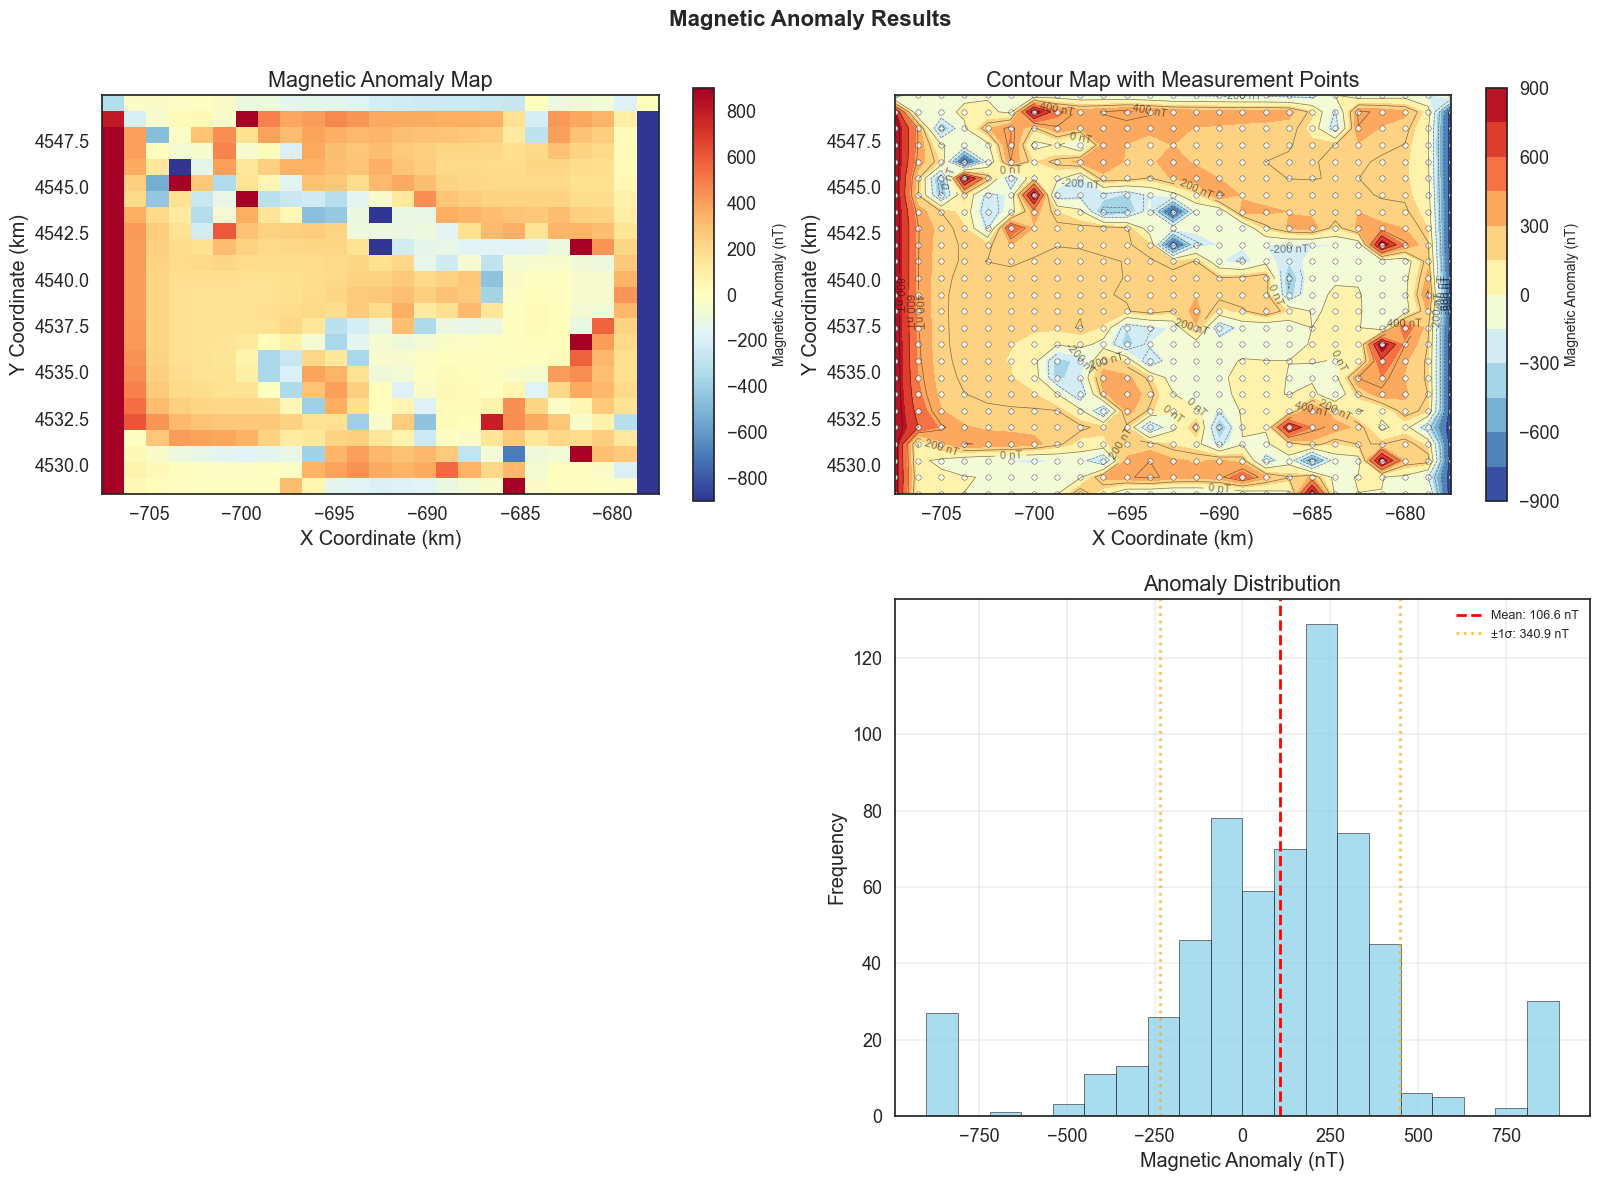

In [ ]:
visualize_magnetic_results(results.clip(-900,900), measurement_points)

# 10. Buried Dipole Forward Modeling Example

BURIED DIPOLE FORWARD MODELING EXAMPLE
Dipole Configuration:
  Center: (0, 0, -800) m
  Radius: 250 m
  Depth: 800 m below surface
  Susceptibility: 0.3000 SI
  Background: 0.0000 SI

Magnetic Field Parameters:
  Strength: 30.0 µT
  Inclination: 30.0°
  Declination: 90.0°

Survey Configuration:
  Elevation: 0 m above surface
  Survey area: 5.0 × 5.0 km
  Measurement grid: 46 × 46 = 2116 points

------------------------------------------------------------
STEP 1: Creating 3D Susceptibility Model
------------------------------------------------------------
Model created:
  Grid: 36 × 36 × 24 = 31,104 voxels
  Voxel size: 194.4 × 194.4 × 95.8 m
  Dipole voxels: 20
  Volume ratio: 0.06%

------------------------------------------------------------
STEP 2: Setting Up Survey Grid
------------------------------------------------------------
Survey grid created:
  Points: 2,116
  Spacing: 111.1 × 111.1 m
  Distance to dipole: 1102.8 to 3702.7 m

------------------------------------------------

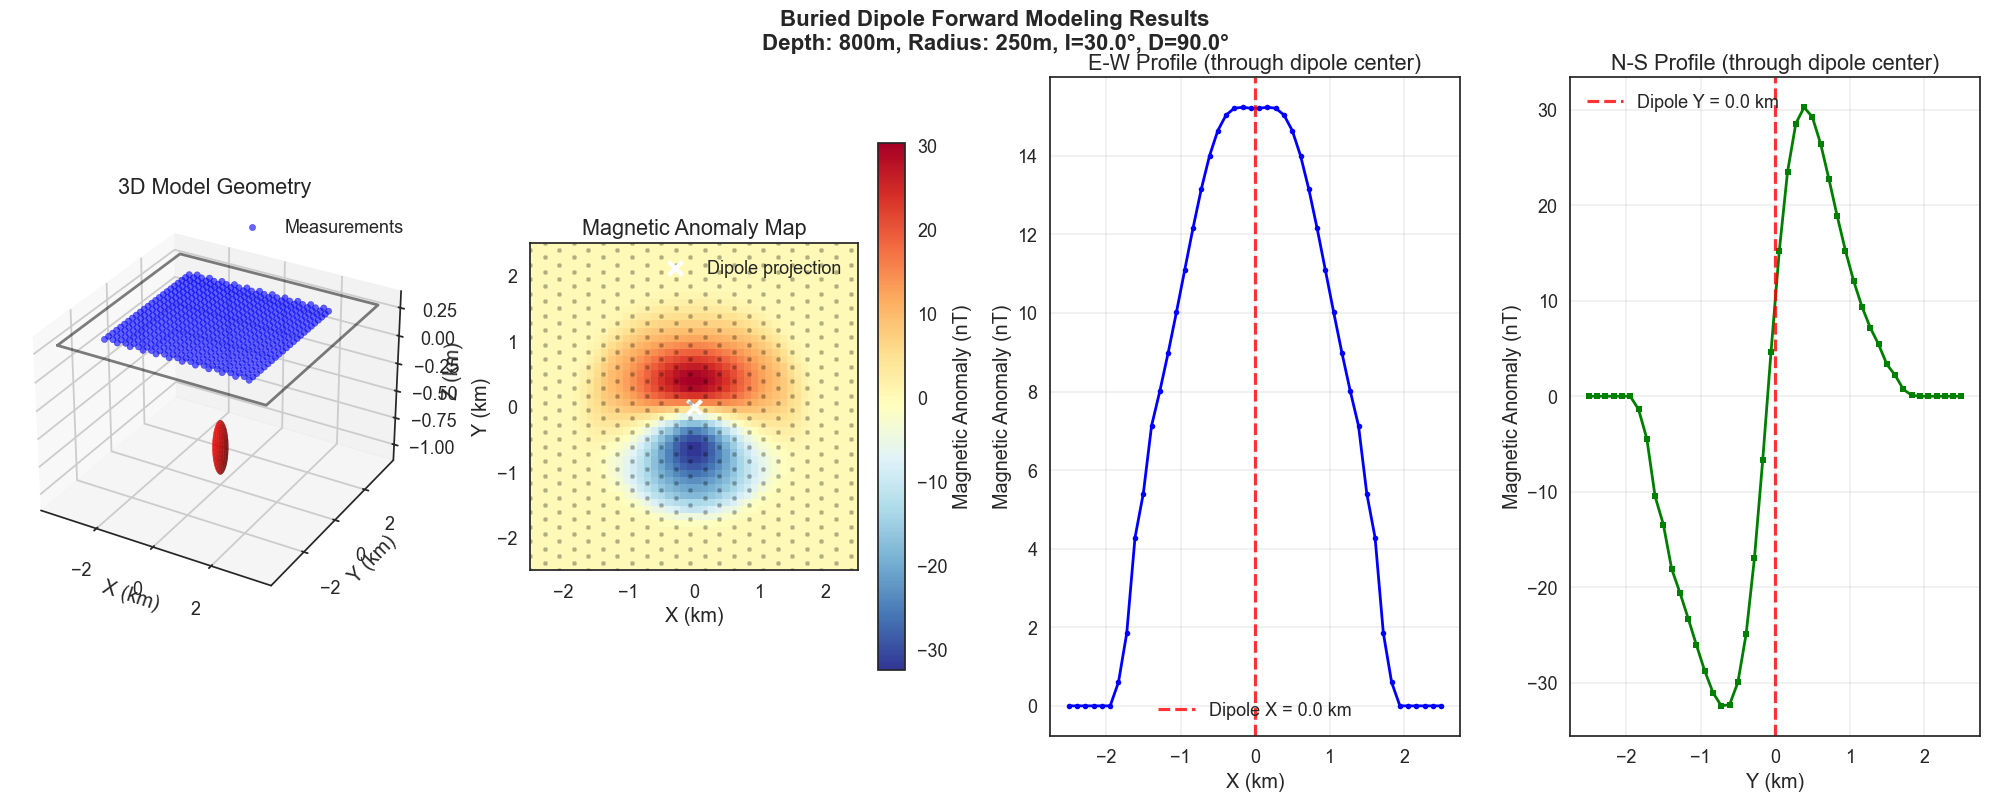

In [77]:
m_extent = 3500
s_extent = 2500

results_experiment = examples.buried_dipole_forward_modeling_example(
    dipole_center=(0, 0, -800),  # 800 metres depth
    dipole_radius=250,
    dipole_susceptibility=0.30,
    background_susceptibility=0.00,
    survey_elevation=0,
    survey_extent = (-s_extent,s_extent,-s_extent,2500),
    survey_resolution=(46, 46),
    model_extent = (-m_extent,m_extent,-m_extent,m_extent,-2000,300),
    model_resolution=(36, 36, 24),
    magnetic_field_params={'B_ext': 30e-6, 'incl': 30, 'decl': 90.0},
    cutoff_distance=2000.0,
    save_results=False
)

# 11. Calculate Misfit with QGIS values

In [ ]:
# Importing cleaned gravity data
magnetic_data = gpd.read_file(os.path.join(geophysical_dir, 'cleaned_magnetic_data.geojson'))

# Create measurement points at gravity data locations
magnetic_measurement_points_QGIS = np.column_stack([
    np.array(magnetic_data.geometry.x.values),
    np.array(magnetic_data.geometry.y.values),
    np.full(len(magnetic_data), max_z)  # Set Z to surface elevation
])

# Sample n random points from the magnetic measurement points
n_sample = 100
sample_indices = np.random.choice(len(magnetic_measurement_points_QGIS), size=n_sample, replace=False)
magnetic_measurement_points_QGIS = magnetic_measurement_points_QGIS[sample_indices]

# Observed gravity values
observed_magnetic = magnetic_data['MAG'].values[sample_indices] # in nT

In [25]:
mag_engine = NumpyMagneticsForwardModeling(cutoff_distance=5000.0)
mag_engine.set_magnetic_parameters(B_ext=50e-6, incl=60.0, decl=0.43)

results = mag_engine.load_and_process_model(
    "your_susceptibility.npy", 
    voxel_centers, 
    voxel_sizes, 
    magnetic_measurement_points_QGIS
)

Loading susceptibility model from your_susceptibility.npy
Loaded susceptibility model with shape: (64, 64, 64)
Processing 100 measurement points with 262144 voxels
Computing volume integrals for 262144 voxels and 100 measurements...
Using distance cutoff: 5.0 km
Pre-computing active voxels within cutoff distance...
  Measurement point 1: 31562/262144 active voxels (12.0%)
Total active voxel-measurement pairs: 2659358 (vs 26214400 without cutoff)
Computational reduction: 89.9%
Processing measurements 1 to 100 of 100
Total active voxel-measurement pairs: 2659358 (vs 26214400 without cutoff)
Computational reduction: 89.9%
Processing measurements 1 to 100 of 100
Volume integrals computed in 3.80 seconds
Computing magnetic forward modeling...
Using compact format with distance cutoff...
Processing 2659358 active voxel-measurement pairs
Volume integrals computed in 3.80 seconds
Computing magnetic forward modeling...
Using compact format with distance cutoff...
Processing 2659358 active voxel

Gravity Misfit Analysis:
  Mean Misfit: 0.120 mGal
  Std Misfit: 0.287 mGal
  Min Residual: -0.774 mGal
  Max Residual: 0.681 mGal


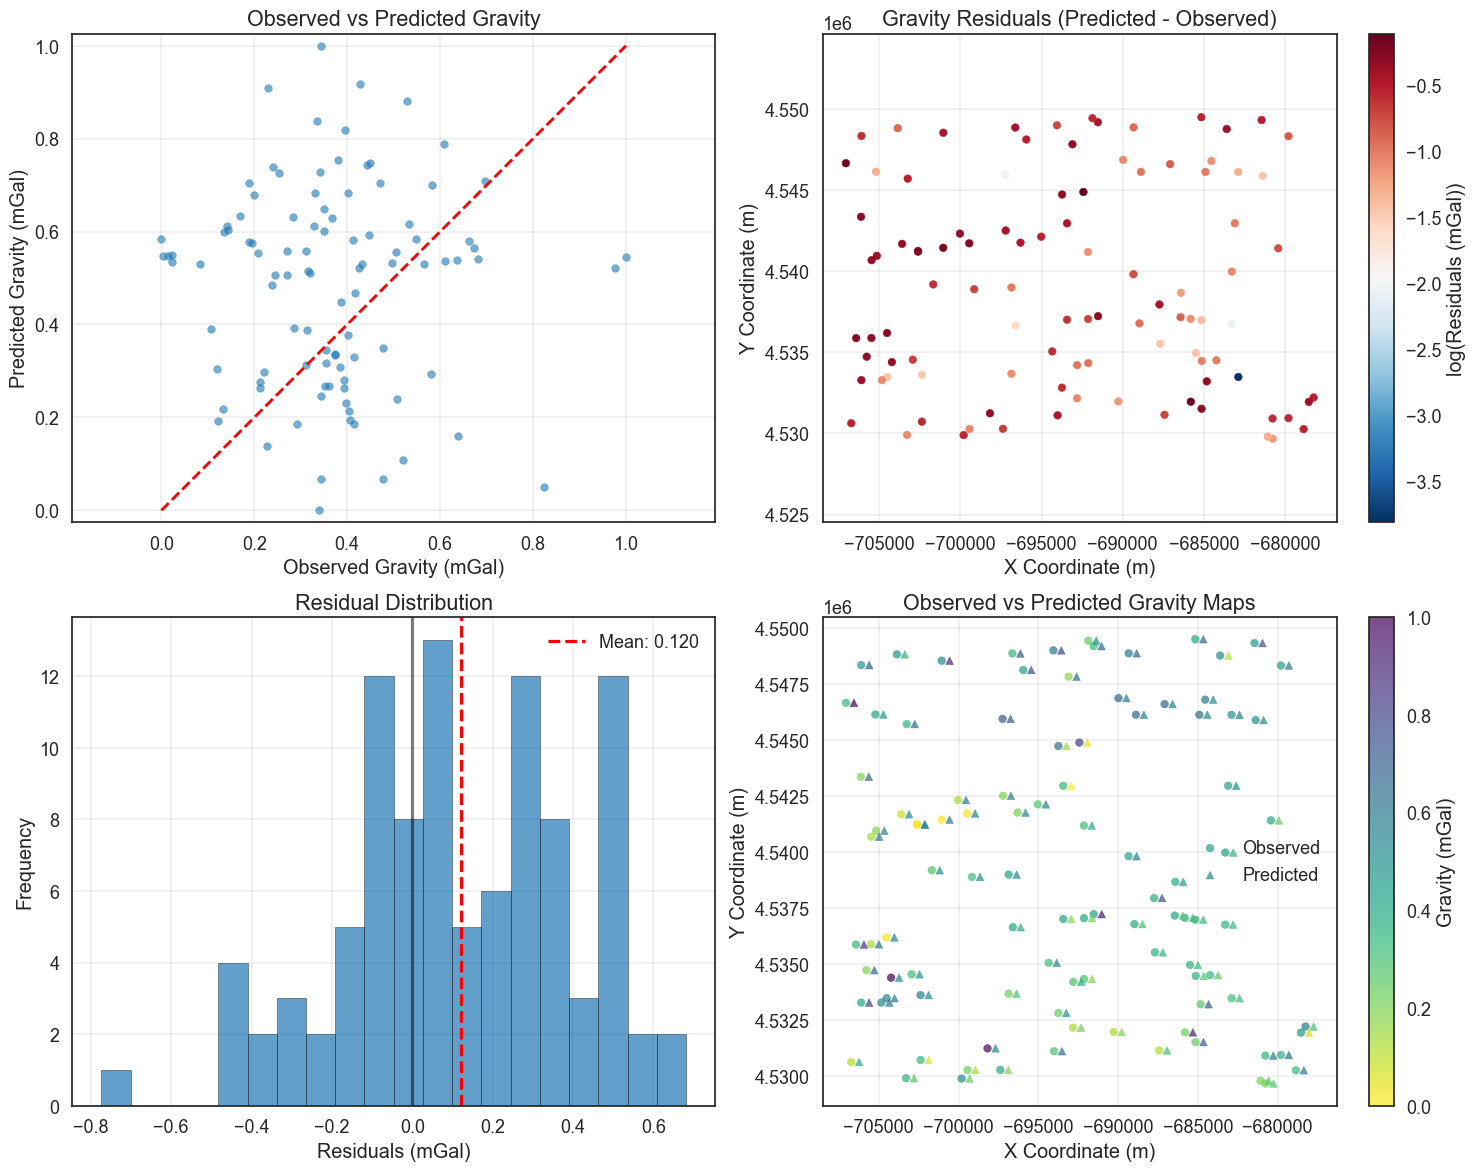

In [36]:
normalised_magnetics          = (results          - np.min(results))          / (np.max(results)          - np.min(results))
normalised_observed_magnetics = (observed_magnetic - np.min(observed_magnetic)) / (np.max(observed_magnetic) - np.min(observed_magnetic))

    
misfit_value = misfit.misfit_geophysical(observed_data = normalised_observed_magnetics, modelled_data = normalised_magnetics, error_formula='MSE')
residuals    = misfit.plot_residuals(observed_data = normalised_observed_magnetics, modelled_data = normalised_magnetics, field_measurement_locations = magnetic_measurement_points_QGIS)